# Goal
Analyze the export performance of semiconductor products (specifically integrated circuits) by destination country to identify high-value markets and trends using trade data.

# Data Loading

| Column                                                 | Description                                                                                         |
| ------------------------------------------------------ | --------------------------------------------------------------------------------------------------- |
| **typeCode**                                           | Type of dataset (e.g., trade data category, usually 'C' for commodity)                              |
| **freqCode**                                           | Frequency of the data (usually annual or monthly)                                                   |
| **refPeriodId**, **refYear**, **refMonth**, **period** | Time indicators — useful for time-series analysis                                                   |
| **reporterCode**, **reporterISO**, **reporterDesc**    | Country that is reporting the trade (e.g., Taiwan)                                                  |
| **flowCode**, **flowDesc**                             | Type of trade: Import or Export                                                                     |
| **partnerCode**, **partnerISO**, **partnerDesc**       | Trade partner (who you're buying from or selling to)                                                |
| **cmdCode**                                            | HS (Harmonized System) commodity code — identifies the product (e.g., 8542 for ICs)                 |
| **cmdDesc**                                            | Product description (e.g., “Electronic integrated circuits”)                                        |
| **qty**, **netWgt**, **grossWgt**                      | Quantity and weight of traded goods (may be True/False if not filled correctly)                     |
| **fobvalue**                                           | **Free On Board** value — cost of goods at point of export (good for export-focused value)          |
| **cifvalue**                                           | **Cost, Insurance, and Freight** — includes shipping/import costs (useful for import-side analysis) |
| **motCode**, **motDesc**                               | Mode of transport (e.g., sea, air)                                                                  |
| **customsCode**, **customsDesc**                       | Customs declaration info                                                                            |
| **qtyUnitCode**, **qtyUnitAbbr**                       | Units of measurement (e.g., kg, pieces)                                                             |
| **isReported**                                         | Whether the data is officially reported (vs. estimated)                                             |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import platform
from pathlib import Path
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
pd.reset_option('display.max_rows')

In [3]:
base_path = Path("D:/Git_folder/Dibimbing---DSDA/Final Project Data Science/data_monthly")


if platform.system() == "Windows":
    base_path = Path("D:/Git_folder/Dibimbing---DSDA/Final Project Data Science/data_monthly")
else:
    base_path = Path("/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly")

file_names = [
    "TradeDataJan25.csv", "TradeDataFeb25.csv", "TradeDataMar25.csv", "TradeDataApr25.csv",
    "TradeDataMay25.csv", "TradeDataJan24.csv", "TradeDataFeb24.csv",
    "TradeDataMar24.csv", "TradeDataApr24.csv", "TradeDataMay24.csv", "TradeDataJune24.csv",
    "TradeDataJuly24.csv", "TradeDataAug24.csv", "TradeDataSep24.csv", "TradeDataOct24.csv",
    "TradeDataNov24.csv", "TradeDataDec24.csv"
]

files = [str(base_path / name) for name in file_names]


schema = pd.read_csv(files[0], dtype=str, encoding="latin1", low_memory=False).columns.tolist()

def read_and_fix(fp):
    df = pd.read_csv(fp, dtype=str, encoding="latin1", low_memory=False)
    df = df.reindex(columns=schema)


    mask = df["freqCode"].str.fullmatch(r"\d{8}", na=False)
    if mask.any():
        cols = df.columns.tolist()
        j = cols.index("freqCode")

        bad = df.loc[mask, cols].copy()
        bad.iloc[:, j+1:] = bad.iloc[:, j:-1].values
        bad.iloc[:, j] = "M"

        rpid = bad["refPeriodId"].str.extract(r"(\d{8})", expand=False)
        ok = rpid.notna()
        bad.loc[ok, "refYear"]  = rpid[ok].str.slice(0, 4)
        bad.loc[ok, "refMonth"] = rpid[ok].str.slice(4, 6).astype(int).astype(str)
        bad.loc[ok, "period"]   = (bad.loc[ok, "refYear"].astype(int)*100 + bad.loc[ok, "refMonth"].astype(int)).astype(str)

        df.loc[mask, cols] = bad.values

    return df

dfs = [read_and_fix(f) for f in files]
merged = pd.concat(dfs, ignore_index=True)

print(merged.iloc[0][["typeCode","freqCode","refPeriodId","refYear","refMonth","period"]])

#merged.to_csv("merged_fixed.csv", index=False, encoding="utf-8")

typeCode              M
freqCode              M
refPeriodId    20250101
refYear            2025
refMonth              1
period           202501
Name: 0, dtype: object


In [4]:
merged

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699995,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,3162403.799,NaN,3162403.799,4,false,true
1699996,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,13065800.275,NaN,13065800.275,4,false,true
1699997,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,7553775.545,NaN,7553775.545,4,false,true
1699998,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,54407010.173,NaN,54407010.173,4,false,true


In [5]:
df = merged
df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699995,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,3162403.799,NaN,3162403.799,4,false,true
1699996,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,13065800.275,NaN,13065800.275,4,false,true
1699997,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,7553775.545,NaN,7553775.545,4,false,true
1699998,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,54407010.173,NaN,54407010.173,4,false,true


# Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700000 entries, 0 to 1699999
Data columns (total 47 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   typeCode                  object
 1   freqCode                  object
 2   refPeriodId               object
 3   refYear                   object
 4   refMonth                  object
 5   period                    object
 6   reporterCode              object
 7   reporterISO               object
 8   reporterDesc              object
 9   flowCode                  object
 10  flowDesc                  object
 11  partnerCode               object
 12  partnerISO                object
 13  partnerDesc               object
 14  partner2Code              object
 15  partner2ISO               object
 16  partner2Desc              object
 17  classificationCode        object
 18  classificationSearchCode  object
 19  isOriginalClassification  object
 20  cmdCode                   object
 21  cmdDesc 

We have 47 tables, but not all of them is useful

In [7]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

typeCode: 1 unique values
freqCode: 1 unique values
refPeriodId: 17 unique values
refYear: 2 unique values
refMonth: 12 unique values
period: 17 unique values
reporterCode: 94 unique values
reporterISO: 94 unique values
reporterDesc: 94 unique values
flowCode: 2 unique values
flowDesc: 2 unique values
partnerCode: 246 unique values
partnerISO: 245 unique values
partnerDesc: 246 unique values
partner2Code: 241 unique values
partner2ISO: 241 unique values
partner2Desc: 241 unique values
classificationCode: 4 unique values
classificationSearchCode: 1 unique values
isOriginalClassification: 1 unique values
cmdCode: 2 unique values
cmdDesc: 2 unique values
aggrLevel: 2 unique values
isLeaf: 1 unique values
customsCode: 1 unique values
customsDesc: 1 unique values
mosCode: 1 unique values
motCode: 1 unique values
motDesc: 1 unique values
qtyUnitCode: 3 unique values
qtyUnitAbbr: 2 unique values
qty: 25946 unique values
isQtyEstimated: 2 unique values
altQtyUnitCode: 4 unique values
altQtyUni

In [8]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print("-" * 40)

Column: typeCode
['M']
1
----------------------------------------
Column: freqCode
['M']
1
----------------------------------------
Column: refPeriodId
['20250101' '20250201' '20250301' '20250401' '20250501' '20240101'
 '20240201' '20240301' '20240401' '20240501' '20240601' '20240701'
 '20240801' '20240901' '20241001' '20241101' '20241201']
17
----------------------------------------
Column: refYear
['2025' '2024']
2
----------------------------------------
Column: refMonth
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12']
12
----------------------------------------
Column: period
['202501' '202502' '202503' '202504' '202505' '202401' '202402' '202403'
 '202404' '202405' '202406' '202407' '202408' '202409' '202410' '202411'
 '202412']
17
----------------------------------------
Column: reporterCode
['36' '100' '70' '76' '51' '56' '32' '31' '84' '28' '52' '68' '191' '208'
 '124' '203' '152' '246' '234' '268' '233' '222' '242' '276' '300' '328'
 '344' '308' '320' '442' '428' '392' '45

(reportercode, reporterdesc, partnercode, partnerdesc, refYear, refMonth, flowcode, flowdesc, cmdCode, cmdDesc, fobvalue, cifvalue, netWgt, grossWgt) Apparently these are the tables that is necessary for this analysis. First, need to copy the original data.

In [9]:
df_copy = df.copy()

In [10]:
df_copy

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699995,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,3162403.799,NaN,3162403.799,4,false,true
1699996,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,13065800.275,NaN,13065800.275,4,false,true
1699997,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,7553775.545,NaN,7553775.545,4,false,true
1699998,M,M,20241201,2024,12,202412,699,IND,India,M,...,0,true,0,false,54407010.173,NaN,54407010.173,4,false,true


In [11]:
# Keep only the necessary columns for analysis
columns_to_keep = [
    'reporterCode', 'reporterDesc', 'partnerCode', 'partnerDesc',
    'period', 'flowCode', 'flowDesc',
    'cmdCode', 'cmdDesc', 'qty', 'fobvalue', 'cifvalue', 'netWgt', 'grossWgt', 'primaryValue'
]
df_copy = df_copy[columns_to_keep]
df_copy.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [12]:
# Split export data
df_copy_export = df_copy[df_copy['flowDesc'] == 'Export']

# Split import data
df_copy_import = df_copy[df_copy['flowDesc'] == 'Import']


In [13]:
df_copy_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [14]:
df_copy_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9306.847,9385.708,5.744,0.004,9385.708
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,666.323,725.776,0.39,0.001,725.776
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8280.091,8568.74,5.062,0,8568.74
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1637.654,1736.472,0.934,0,1736.472
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,1993.038,2012.715,1.232,0,2012.715


# Data Cleaning (Handling Missing Values)

## Export

In [15]:
df_copy_export.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,448832,448832,448832,448832,448832,448832,448832,448832,448832,448832,448832,1359,436658,448832,448832
unique,94,94,245,245,17,1,1,2,2,8205,351379,1349,20886,1453,351379
top,642,Romania,0,World,202410,X,Export,TOTAL,All Commodities,0,1.002,251.036,0,0,1.002
freq,68725,68725,27898,27898,27297,448832,448832,378658,378658,431641,106,2,375536,446890,106


In [16]:
df_copy_export.info()

<class 'pandas.core.frame.DataFrame'>
Index: 448832 entries, 0 to 1697334
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   reporterCode  448832 non-null  object
 1   reporterDesc  448832 non-null  object
 2   partnerCode   448832 non-null  object
 3   partnerDesc   448832 non-null  object
 4   period        448832 non-null  object
 5   flowCode      448832 non-null  object
 6   flowDesc      448832 non-null  object
 7   cmdCode       448832 non-null  object
 8   cmdDesc       448832 non-null  object
 9   qty           448832 non-null  object
 10  fobvalue      448832 non-null  object
 11  cifvalue      1359 non-null    object
 12  netWgt        436658 non-null  object
 13  grossWgt      448832 non-null  object
 14  primaryValue  448832 non-null  object
dtypes: object(15)
memory usage: 54.8+ MB


In [17]:
df_copy_export.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
period               0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue             0
cifvalue        447473
netWgt           12174
grossWgt             0
primaryValue         0
dtype: int64

In [18]:
df_copy_export[df_copy_export.isna().any(axis=1)]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1697330,699,India,834,United Rep. of Tanzania,202412,X,Export,8542,Electronic integrated circuits,4,367.812,NaN,NaN,0,367.812
1697331,699,India,800,Uganda,202412,X,Export,8542,Electronic integrated circuits,4,138.211,NaN,NaN,0,138.211
1697332,699,India,634,Qatar,202412,X,Export,8542,Electronic integrated circuits,2,828.205,NaN,NaN,0,828.205
1697333,699,India,268,Georgia,202412,X,Export,8542,Electronic integrated circuits,2,245.828,NaN,NaN,0,245.828


In [19]:
check = df_copy_export[df_copy_export['netWgt'].isna()]
check.sample(10)

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
1654484,344,"China, Hong Kong SAR",116,Cambodia,202412,X,Export,8542,Electronic integrated circuits,687000,16880.9,NaN,NaN,0,16880.9
592492,608,Philippines,340,Honduras,202401,X,Export,TOTAL,All Commodities,0,52686,NaN,NaN,0,52686
1260607,458,Malaysia,807,North Macedonia,202408,X,Export,8542,Electronic integrated circuits,525417,767501.128,NaN,NaN,0,767501.128
1560437,470,Malta,0,World,202411,X,Export,TOTAL,All Commodities,0,386342023.666,NaN,NaN,0,386342023.666
446216,458,Malaysia,233,Estonia,202505,X,Export,8542,Electronic integrated circuits,11680,15686.542,NaN,NaN,0,15686.542
556345,344,"China, Hong Kong SAR",31,Azerbaijan,202401,X,Export,8542,Electronic integrated circuits,630000,168567.023,NaN,NaN,0,168567.023
357596,642,Romania,0,World,202504,X,Export,8542,Electronic integrated circuits,0,24908.32,NaN,NaN,0,24908.32
274571,608,Philippines,8,Albania,202503,X,Export,8542,Electronic integrated circuits,453,425,NaN,NaN,0.74,425
1564310,392,Japan,788,Tunisia,202411,X,Export,8542,Electronic integrated circuits,13420,39990.72,NaN,NaN,0,39990.72
809941,124,Canada,410,Rep. of Korea,202404,X,Export,8542,Electronic integrated circuits,0,640709.194,NaN,NaN,0,640709.194


In [20]:
# Calculate and display the percentage of missing values for each column in df_copy
percent_missing = df_copy_export.isna().mean() * 100
print(percent_missing)

reporterCode     0.000000
reporterDesc     0.000000
partnerCode      0.000000
partnerDesc      0.000000
period           0.000000
flowCode         0.000000
flowDesc         0.000000
cmdCode          0.000000
cmdDesc          0.000000
qty              0.000000
fobvalue         0.000000
cifvalue        99.697214
netWgt           2.712373
grossWgt         0.000000
primaryValue     0.000000
dtype: float64


we don't need 'cifvalue' in here. ('fobvalue' is a cost of goods at point of export, while 'cifvalue' is a shipping/import costs).

In [21]:
# Check for zero values in selected columns of df_copy_export
zero_counts = df_copy_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [22]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_export['netWgt'].mean()
df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
df_copy_export['netWgt'] = df_copy_export['netWgt'].replace(0, mean_netWgt)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\1051301107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\1051301107.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\1051301107.py:7: SettingWithCopyWarnin

In [23]:
df_export = df_copy_export.drop(columns=['cifvalue'])

In [24]:
# check again
percent_missing_check = df_export.isna().mean() * 100
percent_missing_check

reporterCode    0.0
reporterDesc    0.0
partnerCode     0.0
partnerDesc     0.0
period          0.0
flowCode        0.0
flowDesc        0.0
cmdCode         0.0
cmdDesc         0.0
qty             0.0
fobvalue        0.0
netWgt          0.0
grossWgt        0.0
primaryValue    0.0
dtype: float64

In [25]:
#check again
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


Since we use 'netWgt' the most, we will drop the 'grossWgt' and 'primaryvalue'

In [26]:
df_export.drop(columns=['grossWgt', 'primaryValue'], inplace=True)

In [27]:
df_export = df_export.reset_index(drop=True)
df_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,1532.53173
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,1532.53173
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,1532.53173
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,1532.53173
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,1532.53173


In [28]:
# Check rows where reporterCode is 0 in the check DataFrame
df_export[df_export['partnerCode'] == 0]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt


In [29]:
partner_counts = df_export['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
partner_counts

,Country,Count
0,World,27898
1,Germany,10125
2,Italy,9679
3,Spain,9311
4,Netherlands,8359
...,...,...
240,"Rest of America, nes",37
241,Free Zones,37
242,Bouvet Island,33
243,Heard Island and McDonald Islands,12


In [30]:
df_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448832 entries, 0 to 448831
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  448832 non-null  object 
 1   reporterDesc  448832 non-null  object 
 2   partnerCode   448832 non-null  object 
 3   partnerDesc   448832 non-null  object 
 4   period        448832 non-null  object 
 5   flowCode      448832 non-null  object 
 6   flowDesc      448832 non-null  object 
 7   cmdCode       448832 non-null  object 
 8   cmdDesc       448832 non-null  object 
 9   qty           448832 non-null  object 
 10  fobvalue      448832 non-null  object 
 11  netWgt        448832 non-null  float64
dtypes: float64(1), object(11)
memory usage: 41.1+ MB


## Import (In case we need it)

In [31]:
df_copy_import.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,1251168,1251168,1251168,1251168,1251168,1251168,1251168,1251168,1251168,1251168,472974,1179047,1224626,1251168,1251168
unique,94,94,246,246,17,1,1,2,2,18672,376145,911072,50306,962,974654
top,276,Germany,0,World,202504,M,Import,TOTAL,All Commodities,0,10,1.081,0,0,1.081
freq,142623,142623,71203,71203,75864,1251168,1251168,1110762,1110762,1211416,368,354,1092411,1249285,354


In [32]:
df_copy_import.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1251168 entries, 231 to 1699999
Data columns (total 15 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   reporterCode  1251168 non-null  object
 1   reporterDesc  1251168 non-null  object
 2   partnerCode   1251168 non-null  object
 3   partnerDesc   1251168 non-null  object
 4   period        1251168 non-null  object
 5   flowCode      1251168 non-null  object
 6   flowDesc      1251168 non-null  object
 7   cmdCode       1251168 non-null  object
 8   cmdDesc       1251168 non-null  object
 9   qty           1251168 non-null  object
 10  fobvalue      472974 non-null   object
 11  cifvalue      1179047 non-null  object
 12  netWgt        1224626 non-null  object
 13  grossWgt      1251168 non-null  object
 14  primaryValue  1251168 non-null  object
dtypes: object(15)
memory usage: 152.7+ MB


In [33]:
df_copy_import.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
period               0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue        778194
cifvalue         72121
netWgt           26542
grossWgt             0
primaryValue         0
dtype: int64

In [34]:
# Check for zero values in selected columns of df_copy_import
zero_counts = df_copy_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [35]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_import['netWgt'].mean()
df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
df_copy_import['netWgt'] = df_copy_import['netWgt'].replace(0, mean_netWgt)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\2765187067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\2765187067.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\2765187067.py:7: SettingWithCopyWarnin

In [36]:
# Convert 'cifvalue' to numeric, coerce errors to NaN
df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')

# Calculate median
median_cifvalue = df_copy_import['cifvalue'].median()

# Replace 0 with median
df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\889091190.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_23208\889091190.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)


In [37]:
df_import = df_copy_import.drop(columns=['fobvalue', 'grossWgt', 'primaryValue'])

In [38]:
# check again
percent_missing_check = df_import.isna().mean() * 100
percent_missing_check

reporterCode    0.000000
reporterDesc    0.000000
partnerCode     0.000000
partnerDesc     0.000000
period          0.000000
flowCode        0.000000
flowDesc        0.000000
cmdCode         0.000000
cmdDesc         0.000000
qty             0.000000
cifvalue        5.764294
netWgt          0.000000
dtype: float64

In [39]:
#check again
zero_counts = df_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
cifvalue        0
netWgt          0
dtype: int64


In [40]:
df_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,cifvalue,netWgt
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9385.708,5.744
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,725.776,0.390
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8568.740,5.062
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1736.472,0.934
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,2012.715,1.232


In [41]:
partner_counts = df_import['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
total = partner_counts['Count'].sum()
print(f"Total: {total}")
partner_counts

Total: 1251168


,Country,Count
0,World,71203
1,China,35419
2,USA,28090
3,Germany,24356
4,Italy,23231
...,...,...
241,"Oceania, nes",61
242,"LAIA, nes",38
243,"Rest of America, nes",13
244,"North America and Central America, nes",12


## Unique Findings !!
#### Exporters

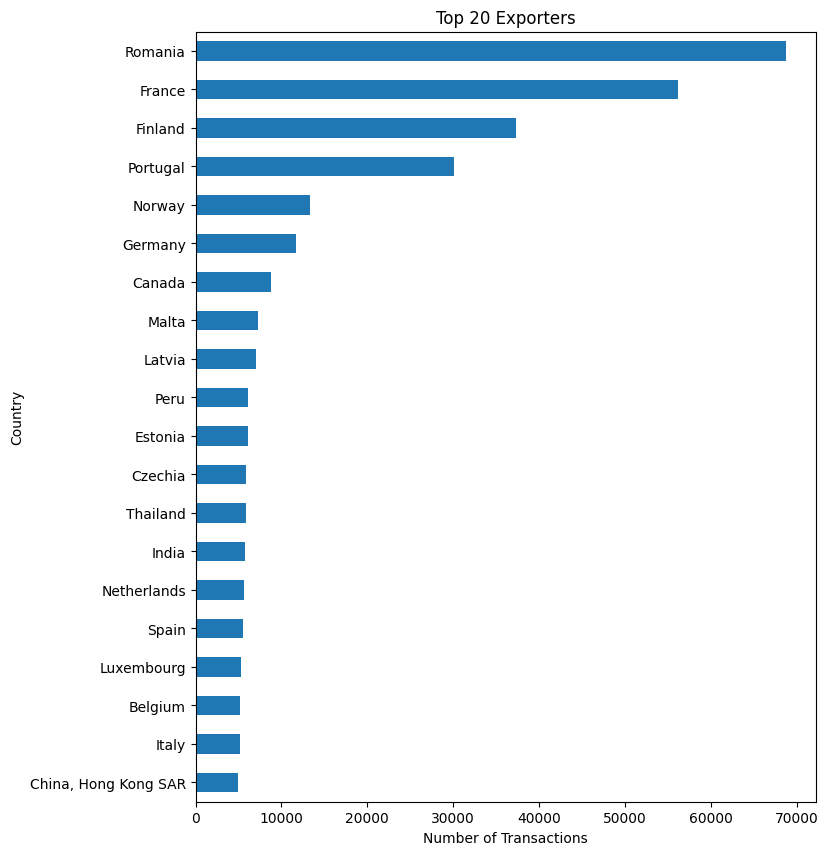

In [42]:
# From df_export
df_export['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Exporters")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

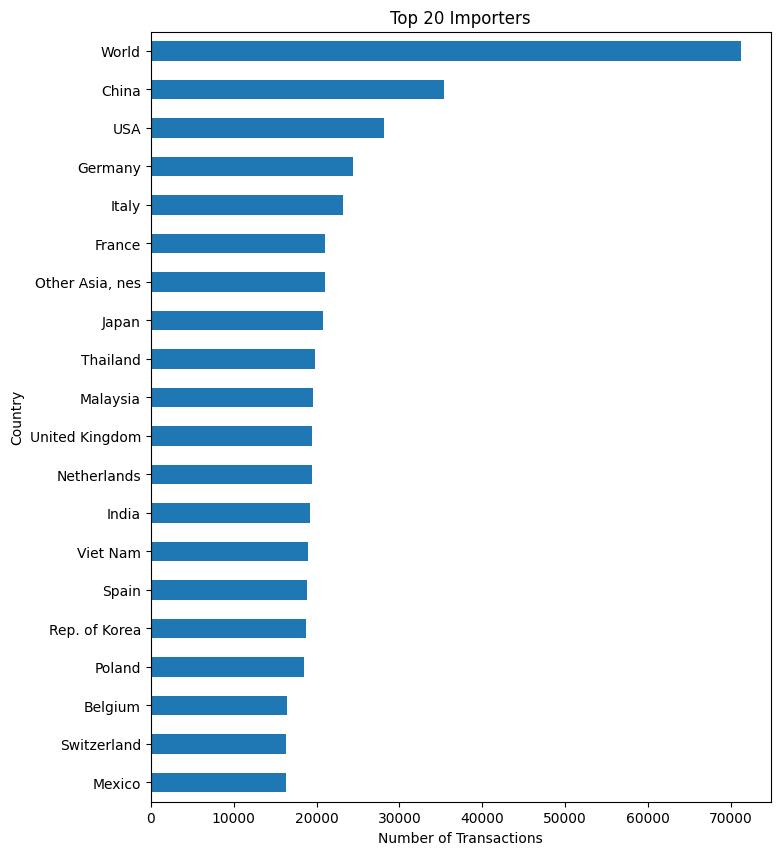

In [43]:
# From df_import
df_import['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Importers

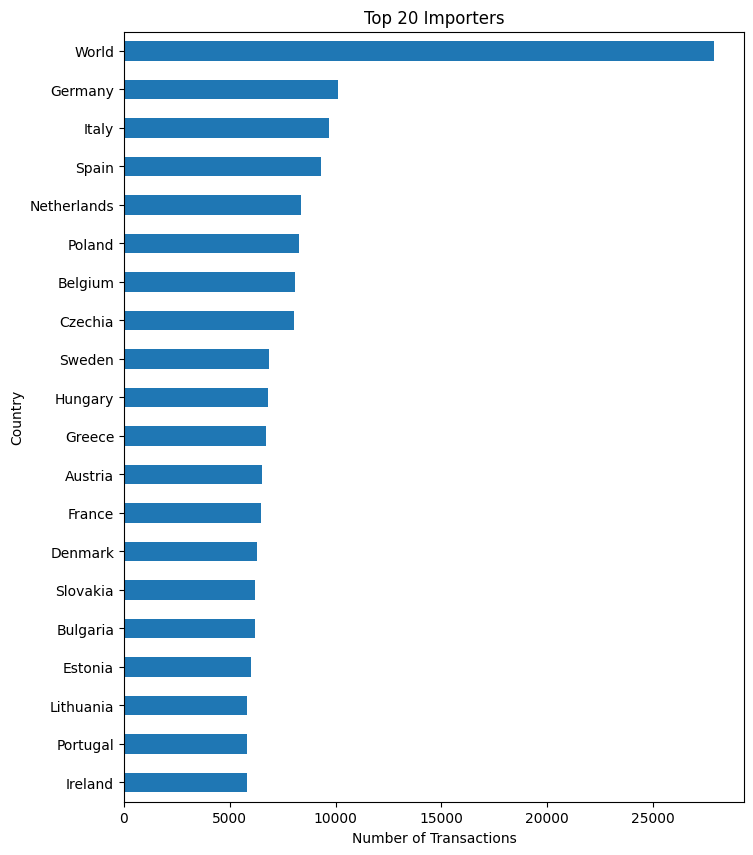

In [44]:
# From df_export
df_export['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

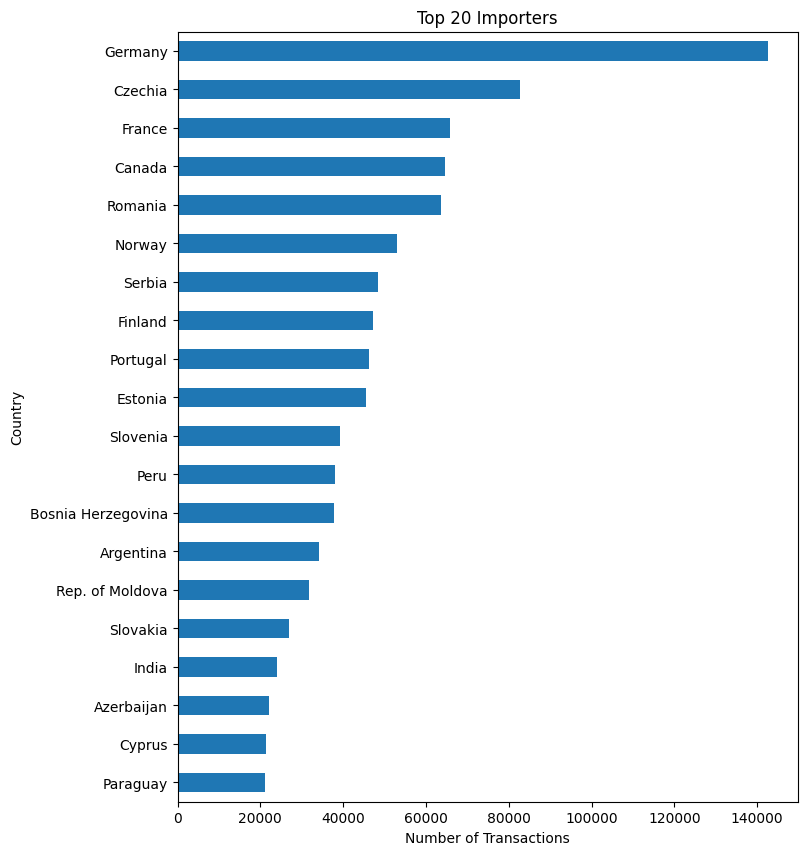

In [45]:
# From df_import
df_import['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Insight:
We can take a data either import or export from both export report or import report. However, we will have some aggregation data from the opposite report such as taking an export data from import report which exporter will be as 'partner' and the 'reporter' will be the import country. The reporter somehow create a aggregation data such as 'World' as their 'partner'. So we have to focus on the 'reporter' only to avoid aggregation data.

# Outlier Check

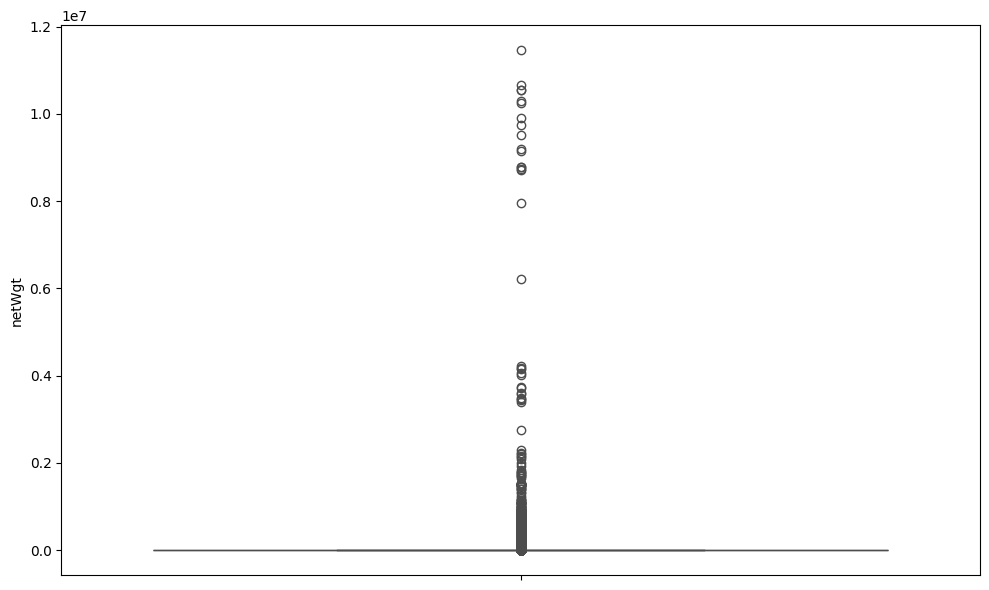

In [46]:
# Check outliers
numerical_columns = df_export.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=df_export[numerical_columns[i]], color='blue')
    plt.tight_layout()

Since the operations value is the part that has outliers, we will keep the outliers, to keep the original information.

# Export Data for PBI uses

In [47]:
df_export.to_excel('df_export.xlsx', index=False)

ModuleNotFoundError: No module named 'openpyxl'

In [ ]:
df_import.to_excel('df_import.xlsx', index=False)

## Data of the quantity

In [ ]:
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [ ]:
# Drop rows where 'qty' is zero in df_export
df_export_qty = df_export[df_export['qty'] != 0].reset_index(drop=True)
df_export_qty.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,1515.220819
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,1515.220819
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,1515.220819
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,1515.220819
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,1515.220819


In [ ]:
zero_counts = df_export_qty.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [ ]:
df_export_qty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462778 entries, 0 to 462777
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  462778 non-null  object 
 1   reporterDesc  462778 non-null  object 
 2   partnerCode   462778 non-null  object 
 3   partnerDesc   462778 non-null  object 
 4   period        462778 non-null  object 
 5   flowCode      462778 non-null  object 
 6   flowDesc      462778 non-null  object 
 7   cmdCode       462778 non-null  object 
 8   cmdDesc       462778 non-null  object 
 9   qty           462778 non-null  object 
 10  fobvalue      462778 non-null  object 
 11  netWgt        462778 non-null  float64
dtypes: float64(1), object(11)
memory usage: 42.4+ MB


In [ ]:
df_export_qty.to_excel('df_export_qty.xlsx', index=False)

KeyboardInterrupt: 

# Data Manipulation

In [ ]:
# Select only columns with float or int data types from df_copy_clean
numeric_df = df_export.select_dtypes(include=['float64', 'int64'])
numeric_df.head()

,netWgt
0,1515.220819
1,1515.220819
2,1515.220819
3,1515.220819
4,1515.220819


In [ ]:
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

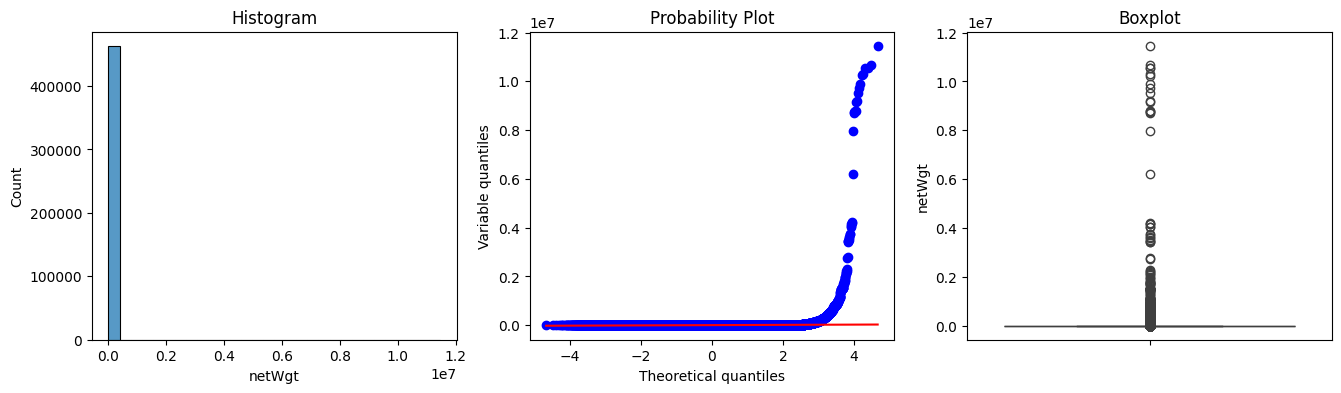

In [ ]:
for col in numeric_df:
    check_plot(numeric_df, col)

There is nothing to conclude yet here.

In [ ]:
# Convert fobvalue to numeric before aggregation
df_export['fobvalue'] = pd.to_numeric(df_export['fobvalue'], errors='coerce')
top_countries = df_export.groupby('reporterDesc')['fobvalue'].mean().sort_values(ascending=False).reset_index()
top_countries.head(10)

,reporterDesc,fobvalue
0,China,1.815496e+09
1,USA,1.135350e+09
2,Germany,8.341748e+08
3,Mexico,7.623158e+08
4,"China, Hong Kong SAR",5.035496e+08
5,Rep. of Korea,4.922281e+08
6,Japan,4.707945e+08
7,Italy,3.768041e+08
8,Netherlands,3.640837e+08
9,Canada,3.630494e+08


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\1022818561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')


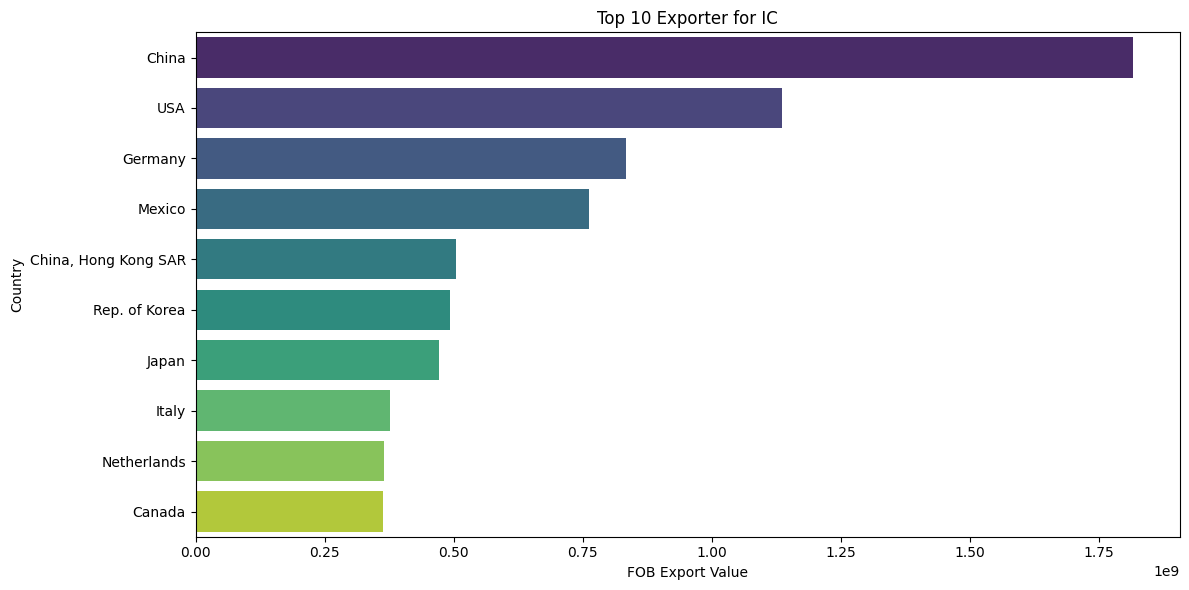

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')
plt.title('Top 10 Exporter for IC')
plt.xlabel('FOB Export Value')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

<Axes: xlabel='period'>

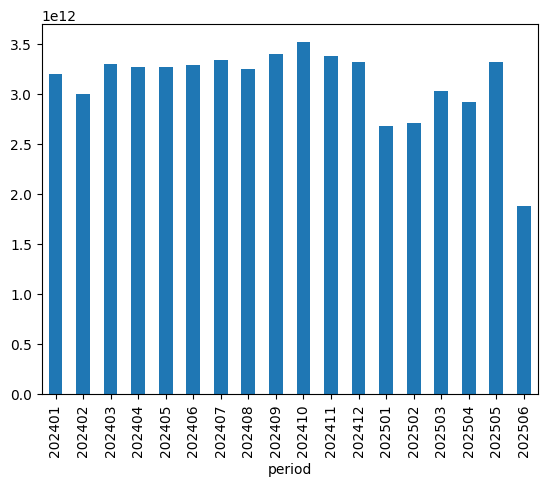

In [ ]:
df_export.groupby(['period'])['fobvalue'].sum().plot(kind='bar')

In [ ]:
# a. Trend analysis over time
trend_df = df_export.groupby("period")["fobvalue"].sum().reset_index()
trend_df

,period,fobvalue
0,202401,3.202391e+12
1,202402,2.999158e+12
2,202403,3.298153e+12
3,202404,3.272380e+12
4,202405,3.271208e+12
5,202406,3.284416e+12
6,202407,3.334472e+12
7,202408,3.242478e+12
8,202409,3.395185e+12
9,202410,3.517545e+12


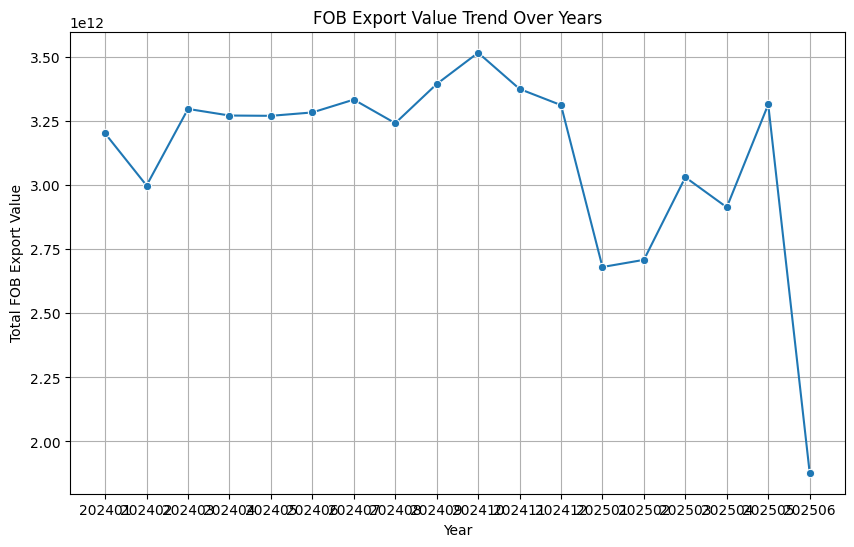

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_df, x='period', y='fobvalue', marker='o')
plt.title('FOB Export Value Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total FOB Export Value')
plt.grid(True)
plt.show()

In [ ]:
# Calculate export value per kg
df_export["value_per_kg"] = df_export["fobvalue"] / df_export["netWgt"]

In [ ]:
# b. Avg export value/kg by country
value_per_kg_df = df_export.groupby("reporterDesc")["value_per_kg"].mean().reset_index()
value_per_kg_df = value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)
value_per_kg_df

,reporterDesc,value_per_kg
17,China,1.147880e+06
90,USA,7.492966e+05
35,Germany,5.454561e+05
58,Mexico,5.031042e+05
47,Japan,3.042146e+05
18,"China, Hong Kong SAR",2.904569e+05
75,Rep. of Korea,2.771839e+05
46,Italy,2.487865e+05
64,Netherlands,2.397157e+05
15,Canada,2.396016e+05


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\769833094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


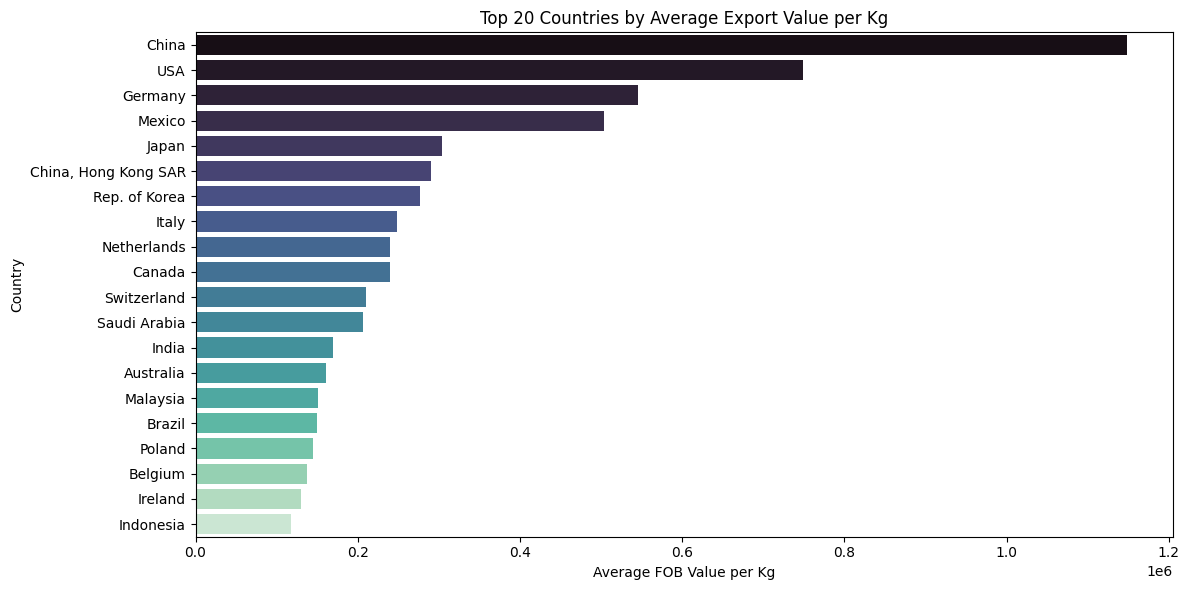

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
importer_value_per_kg_df = df_export.groupby("partnerDesc").agg(
    total_fobvalue=("fobvalue", "sum"),
    total_netwgt=("netWgt", "sum")
).reset_index()

In [ ]:
# Calculate value per kg
importer_value_per_kg_df["value_per_kg"] = (
    importer_value_per_kg_df["total_fobvalue"] / importer_value_per_kg_df["total_netwgt"]
)
importer_value_per_kg_df = importer_value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\491785898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\491785898.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


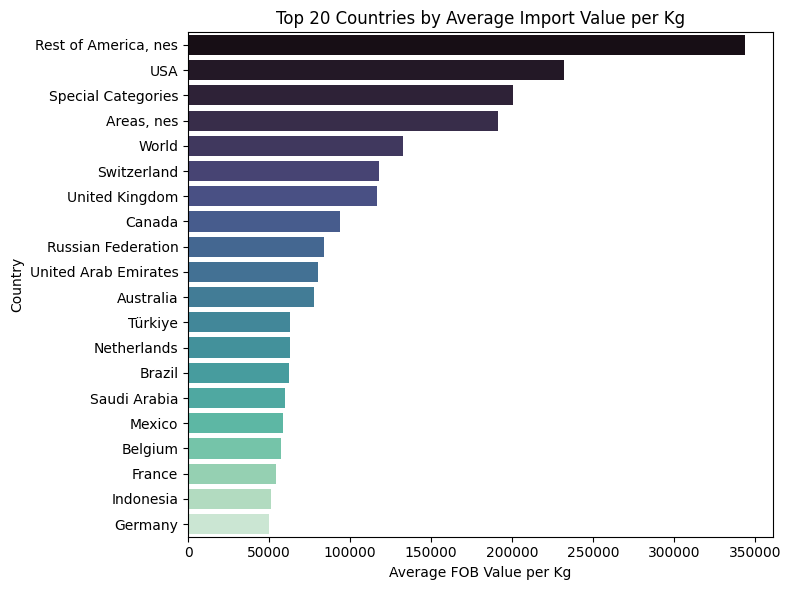

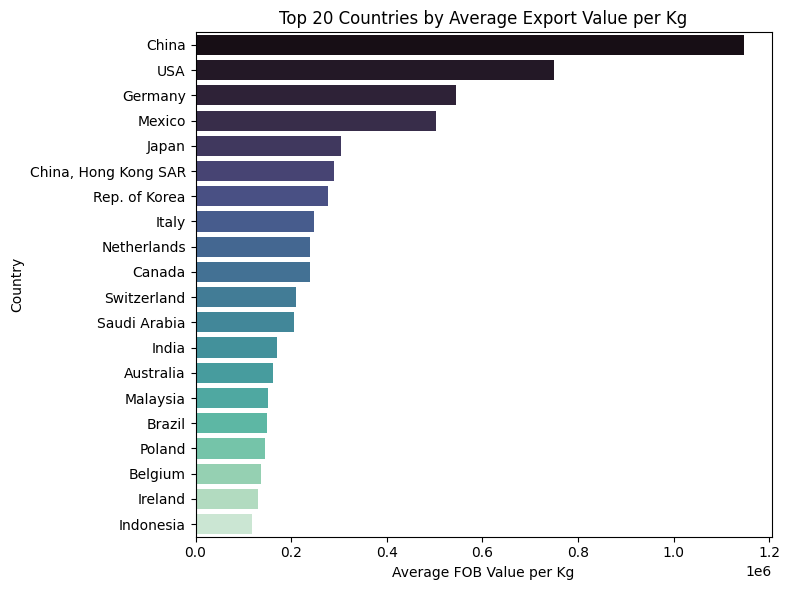

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
plt.title('Top 20 Countries by Average Import Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.figure(figsize=(8, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.show()

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\101735088.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")


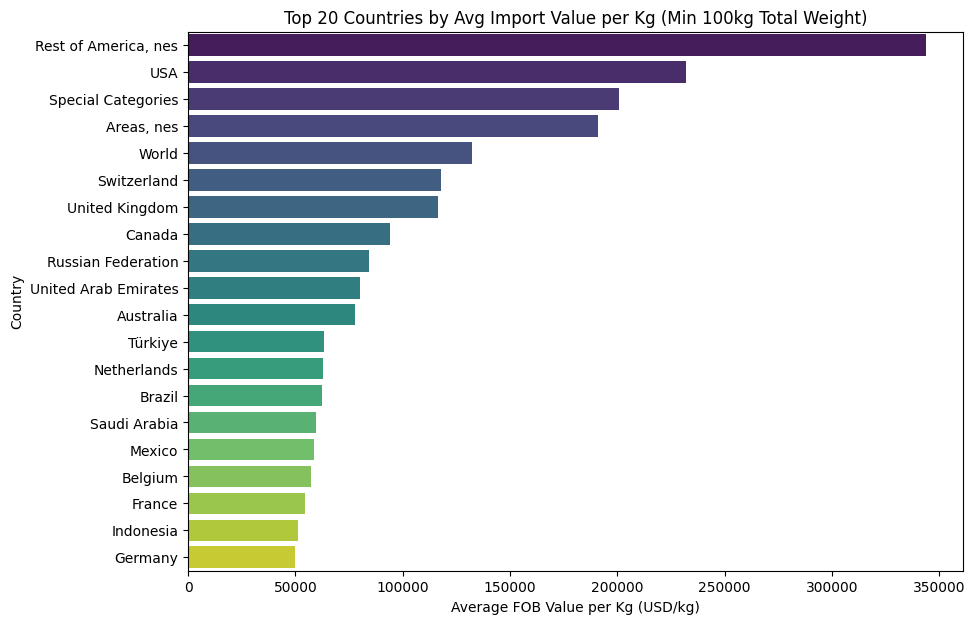

In [ ]:
# Apply threshold: remove countries with too small total weight (e.g., <100kg)
filtered_df = importer_value_per_kg_df[importer_value_per_kg_df["total_netwgt"] > 100]

# Get top 20 by FOB value
top_importers_filtered = filtered_df.sort_values(by="value_per_kg", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")
plt.title("Top 20 Countries by Avg Import Value per Kg (Min 100kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.show()


Move to PBI to make a complete visualization, and conclusion. Business recommendation is in Powerpoint.

In [ ]:
# Top exporters by FOB
top_exp = (df_copy_export.groupby('reporterDesc')['fobvalue']
                 .sum().sort_values(ascending=False).head(10))

# Convert netWgt and fobvalue to numeric
df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
df_copy_export['fobvalue'] = pd.to_numeric(df_copy_export['fobvalue'], errors='coerce')

# Weighted $/kg with a weight floor (e.g., 1,000 kg)
g = df_copy_export[(df_copy_export['netWgt'] > 0) & (df_copy_export['fobvalue'] > 0)] \
        .groupby('reporterDesc').agg(val=('fobvalue','sum'),
                                     wgt=('netWgt','sum'))
g['usd_per_kg'] = g['val'] / g['wgt']
price_rank = g[g['wgt'] >= 1000].sort_values('usd_per_kg', ascending=False).head(10)

C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\535947027.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\535947027.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['fobvalue'] = pd.to_numeric(df_copy_export['fobvalue'], errors='coerce')


x value (usd_per_kg):
reporterDesc
USA             749296.629544
Mexico          502810.898751
Canada          239601.621297
Switzerland     237964.153868
Saudi Arabia    180726.951424
India           179880.094660
Brazil          173297.349373
Australia       161743.535628
Netherlands     142555.960519
Ireland         140112.006628
Name: usd_per_kg, dtype: float64


C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\2912927662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
C:\Users\Predator Helios Neo\AppData\Local\Temp\ipykernel_22828\2912927662.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


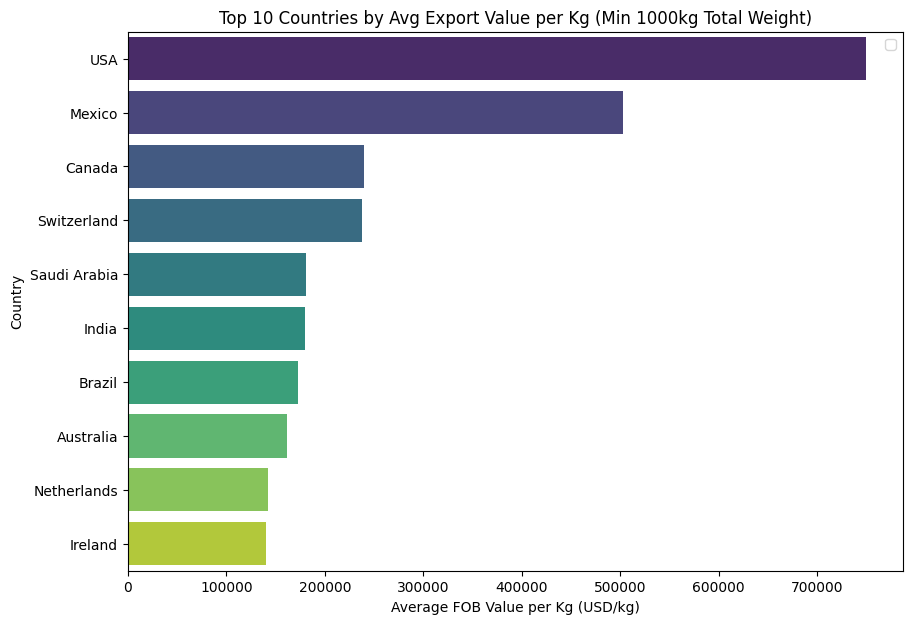

In [ ]:
# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
plt.title("Top 10 Countries by Avg Export Value per Kg (Min 1000kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.legend()
print("x value (usd_per_kg):")
print(price_rank['usd_per_kg'])
plt.show()

# Machine learning

In [86]:
# ---------- 1) Parameters ---------------------------------------------------------
value_col = "total_value"   # <- set to "total_kg" if you want Net Weight instead
season    = 12
horizon   = 7               # 6 months of future forecast

In [107]:
def decomp_forecast_multiplicative_flex(
    monthly_df, value_col="total_value", 
    ma_window=12,          # <-- change to 6 for MA6
    season=12,             # <-- keep 12 unless you truly have 6-month seasonality
    horizon=6
):
    """
    Multiplicative decomposition with a flexible MA window for trend (CMA)
    and a possibly different seasonal period for seasonal indices.
    """
    df = monthly_df[["ref_date", value_col]].dropna().copy()
    df = df.sort_values("ref_date").reset_index(drop=True)
    s = df.set_index("ref_date")[value_col].astype(float)

    # Ensure continuous monthly index
    idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(idx)

    if len(s) < ma_window + 1:
        raise ValueError(f"Need at least {ma_window+1} months; have {len(s)}.")

    # ---- CMA (centered moving average) using ma_window ----
    if ma_window % 2 == 1:
        # odd window: true centered rolling mean
        cma = s.rolling(ma_window, center=True).mean()
    else:
        # even window: average adjacent MA to center between months
        ma = s.rolling(ma_window, center=False).mean()
        cma = (ma + ma.shift(-1)) / 2.0

    # ---- Seasonal ratios: Actual / CMA (only where CMA exists) ----
    ratios = (s / cma).dropna()

    # ---- Seasonal indices (SI) ----
    # Option A (default): calendar seasonality (12 months by month-of-year)
    # If `season == 12`, use calendar months. Otherwise, use a generic cycle index 1..season.
    if season == 12:
        # average ratios by calendar month number
        si_by = ratios.groupby(ratios.index.month).mean()
        index_labels = pd.Index(range(1, 13), name="month")
    else:
        # generic cycle index repeating 1..season
        cyc_idx = pd.Series(np.arange(len(s)), index=s.index) % season + 1
        # align to ratios index
        cyc_idx = cyc_idx.reindex(ratios.index)
        si_by = ratios.groupby(cyc_idx).mean()
        index_labels = pd.Index(range(1, season + 1), name="cycle")

    # Fill missing buckets then normalize to mean = 1
    si_by = si_by.reindex(index_labels)
    if si_by.isna().any():
        si_by = si_by.fillna(si_by.dropna().mean())
    si_norm = si_by / si_by.mean()

    # ---- Expand SI to the full timeline ----
    si_series = pd.Series(index=s.index, dtype=float)
    if season == 12:
        for m in range(1, 13):
            si_series[s.index.month == m] = float(si_norm.loc[m])
    else:
        cyc_full = (np.arange(len(s)) % season) + 1
        for k in range(1, season + 1):
            si_series.iloc[cyc_full == k] = float(si_norm.loc[k])

    # ---- Deseasonalize and fit linear trend y ≈ a + b t ----
    deseason = s / si_series
    mask = deseason.notna().values
    t = np.arange(len(deseason))[mask]
    y = deseason[mask].values
    if len(t) < 2:
        raise ValueError("Not enough points to fit a trend.")
    b, a = np.polyfit(t, y, deg=1)  # slope b, intercept a

    trend_hat = pd.Series(np.nan, index=deseason.index)
    trend_hat.iloc[mask] = a + b * t

    # Fitted, re-seasonalized (in-sample)
    ltwS_fitted = trend_hat * si_series

    # ---- Forecast next horizon months ----
    last_date = s.index.max()
    future_idx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    t_future   = np.arange(len(deseason), len(deseason) + horizon)
    trend_future = a + b * t_future

    # Seasonal indices for future months
    if season == 12:
        si_future = pd.Series([float(si_norm.loc[m]) for m in future_idx.month], index=future_idx)
    else:
        cyc_future = (np.arange(len(s), len(s) + horizon) % season) + 1
        si_future = pd.Series([float(si_norm.loc[k]) for k in cyc_future], index=future_idx)

    yhat_future = trend_future * si_future.values

    # ---- Outputs ----
    components = pd.DataFrame({
        "ref_date": s.index,
        "Actual": s.values,
        "CMA": cma.values,
        "SI": si_series.values,
        "Deseasonalized": deseason.values,
        "Trend(a+bt)": trend_hat.values,
        "LTwS_fitted": ltwS_fitted.values
    }).set_index("ref_date")

    forecast = pd.DataFrame({
        "ref_date": future_idx,
        "Trend(a+bt)_future": trend_future,
        "SI_future": si_future.values,
        "Forecast_LTwS": yhat_future
    })

    # In-sample accuracy
    common = components.dropna(subset=["Actual","Trend(a+bt)","LTwS_fitted"])
    MAD_LT   = float(np.mean(np.abs(common["Actual"] - common["Trend(a+bt)"]))) if not common.empty else np.nan
    MAD_LTwS = float(np.mean(np.abs(common["Actual"] - common["LTwS_fitted"]))) if not common.empty else np.nan

    meta = {"intercept_a": a, "slope_b": b, "MAD_LT": MAD_LT, "MAD_LTwS": MAD_LTwS,
            "ma_window": ma_window, "season": season}
    return components, forecast, si_norm, meta

In [108]:
# ---------- 3) Run decomposition on the metric you chose -------------------------
components, forecast_6, seasonal_indices, meta = decomp_forecast_multiplicative_flex(
    monthly, value_col="total_value", ma_window=6, season=6, horizon=6
)


In [109]:
# ---------- 4) Excel-like table (history + future) -------------------------------
hist_tbl = components.reset_index().copy()
hist_tbl["month_label"] = hist_tbl["ref_date"].dt.strftime("%Y-%m")
# Merge future rows (with NaNs for in-sample-only columns)
future_tbl = forecast_6.copy()
future_tbl["month_label"] = future_tbl["ref_date"].dt.strftime("%Y-%m")
table_full = pd.concat([
    hist_tbl[["ref_date","month_label","Actual","CMA","SI","Deseasonalized","Trend(a+bt)","LTwS_fitted"]],
    future_tbl[["ref_date","month_label","Trend(a+bt)_future","SI_future","Forecast_LTwS"]]
], ignore_index=True).sort_values("ref_date").reset_index(drop=True)

print(f"Using metric: {value_col}  (set value_col='total_kg' for Net Weight)")
print(f"Linear trend: y = a + b*t,  a={meta['intercept_a']:.3g},  b={meta['slope_b']:.3g}")
print(f"MAD LT (Actual vs Trend):       {meta['MAD_LT']:.3g}")
print(f"MAD LTwS (Actual vs Trend*SI):  {meta['MAD_LTwS']:.3g}")

display(table_full.tail(20))  # show the last rows including the future 6 months


Using metric: total_value  (set value_col='total_kg' for Net Weight)
Linear trend: y = a + b*t,  a=3.36e+12,  b=-2.1e+10
MAD LT (Actual vs Trend):       1.72e+11
MAD LTwS (Actual vs Trend*SI):  1.57e+11


,ref_date,month_label,Actual,CMA,SI,Deseasonalized,Trend(a+bt),LTwS_fitted,Trend(a+bt)_future,SI_future,Forecast_LTwS
3,2024-04-01,2024-04,3.272380e+12,NaN,1.030709,3.174883e+12,3.296317e+12,3.397543e+12,NaN,NaN,NaN
4,2024-05-01,2024-05,3.271208e+12,NaN,1.024241,3.193789e+12,3.275357e+12,3.354754e+12,NaN,NaN,NaN
5,2024-06-01,2024-06,3.284416e+12,3.232291e+12,1.028482,3.193460e+12,3.254397e+12,3.347089e+12,NaN,NaN,NaN
6,2024-07-01,2024-07,3.334472e+12,3.263574e+12,0.946684,3.522266e+12,3.233437e+12,3.061042e+12,NaN,NaN,NaN
7,2024-08-01,2024-08,3.242478e+12,3.291937e+12,0.942655,3.439730e+12,3.212477e+12,3.028257e+12,NaN,NaN,NaN
8,2024-09-01,2024-09,3.395185e+12,3.320454e+12,1.027230,3.305184e+12,3.191517e+12,3.278423e+12,NaN,NaN,NaN
9,2024-10-01,2024-10,3.517545e+12,3.349622e+12,1.030709,3.412744e+12,3.170558e+12,3.267921e+12,NaN,NaN,NaN
10,2024-11-01,2024-11,3.376069e+12,3.360744e+12,1.024241,3.296168e+12,3.149598e+12,3.225946e+12,NaN,NaN,NaN
11,2024-12-01,2024-12,3.313017e+12,3.308671e+12,1.028482,3.221269e+12,3.128638e+12,3.217748e+12,NaN,NaN,NaN
12,2025-01-01,2025-01,2.680988e+12,3.209754e+12,0.946684,2.831979e+12,3.107678e+12,2.941988e+12,NaN,NaN,NaN


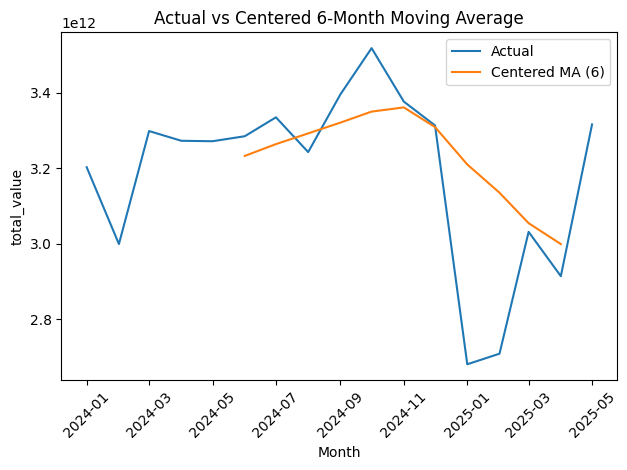

In [112]:
# ---------- 5) Plots like your Excel --------------------------------------------
# A) CMA vs Actual (smoothed level)
plt.figure()
plt.plot(components.index, components["Actual"], label="Actual")
plt.plot(components.index, components["CMA"], label="Centered MA (6)")
plt.title("Actual vs Centered 6-Month Moving Average")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

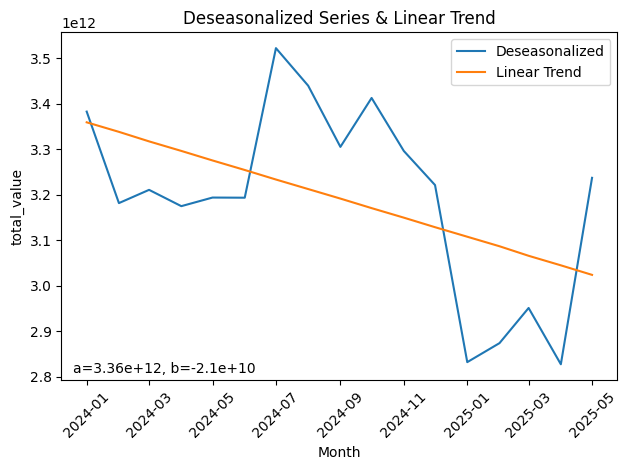

In [113]:
# B) Linear Trend on deseasonalized, with intercept/slope annotated
plt.figure()
plt.plot(components.index, components["Deseasonalized"], label="Deseasonalized")
plt.plot(components.index, components["Trend(a+bt)"], label="Linear Trend")
plt.title("Deseasonalized Series & Linear Trend")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend()
# annotate a and b
x0, x1 = 0, len(components.dropna(subset=["Trend(a+bt)"])) - 1
plt.text(0.02, 0.02, f"a={meta['intercept_a']:.3g}, b={meta['slope_b']:.3g}",
         transform=plt.gca().transAxes)
plt.tight_layout(); plt.show()

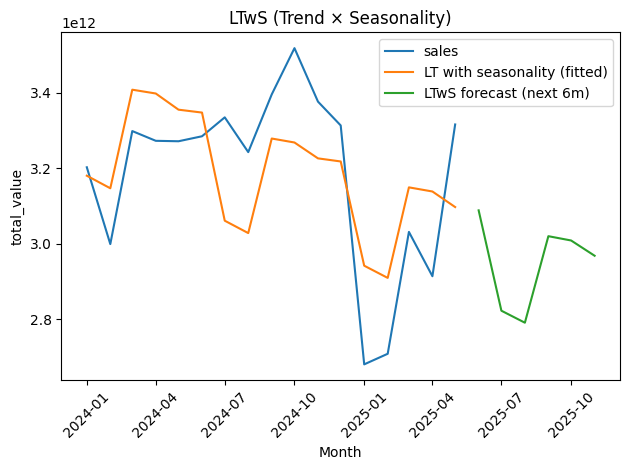

In [114]:
# C) Linear Trend WITH Seasonality (LTwS): show history (fitted) + future 6m
plt.figure()
# Use fitted LTwS where available
plt.plot(components.index, components["Actual"], label="sales")
plt.plot(components.index, components["LTwS_fitted"], label="LT with seasonality (fitted)")
# Append future forecast
plt.plot(forecast_6["ref_date"], forecast_6["Forecast_LTwS"], label="LTwS forecast (next 6m)")
plt.title("LTwS (Trend × Seasonality)")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

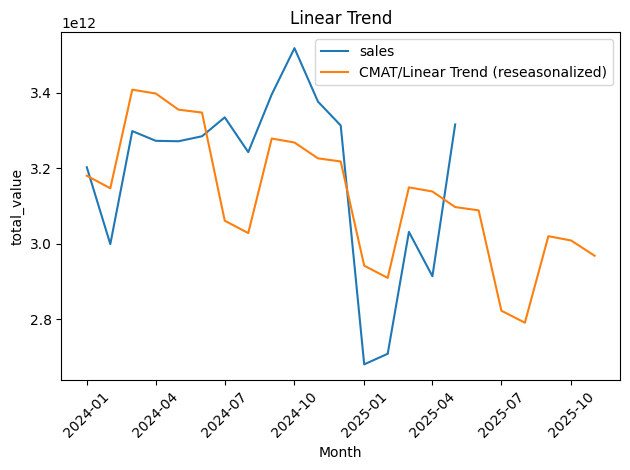

In [115]:
# D) (Optional) “Linear Trend” view like your top chart:
#    plot original (Actual) against reseasonalized trend (fitted + future)
plt.figure()
plt.plot(components.index, components["Actual"], label="sales")
# build a single series that stitches fitted LTwS + future LTwS
stitched = pd.concat([
    components["LTwS_fitted"].dropna().rename("LT reseasonalized (in-sample)"),
    forecast_6.set_index("ref_date")["Forecast_LTwS"].rename("LT reseasonalized (future)")
]).sort_index()
plt.plot(stitched.index, stitched.values, label="CMAT/Linear Trend (reseasonalized)")
plt.title("Linear Trend")
plt.xlabel("Month"); plt.ylabel(value_col); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

{'trend_intercept_a': np.float64(3604921540443.102), 'trend_slope_b': np.float64(-37778423312.43126), 'ma_window': 6, 'season': 12, 'shrink': 0.4, 'recent_start': '2024-10-01 00:00:00'}


,ref_date,Trend_only,SI_used,Forecast_decomp,Forecast_SNaive12,lo_95,hi_95
0,2025-06-01,2.962688e+12,1.022993,3.030809e+12,3.284416e+12,2.648262e+12,3.413357e+12
1,2025-07-01,2.924910e+12,1.026425,3.002200e+12,3.334472e+12,2.619653e+12,3.384748e+12
2,2025-08-01,2.887131e+12,1.003894,2.898375e+12,3.242478e+12,2.515827e+12,3.280922e+12
3,2025-09-01,2.849353e+12,1.026905,2.926014e+12,3.395185e+12,2.543467e+12,3.308561e+12
4,2025-10-01,2.811575e+12,1.043842,2.934839e+12,3.517545e+12,2.552292e+12,3.317387e+12
5,2025-11-01,2.773796e+12,1.015902,2.817904e+12,3.376069e+12,2.435357e+12,3.200451e+12


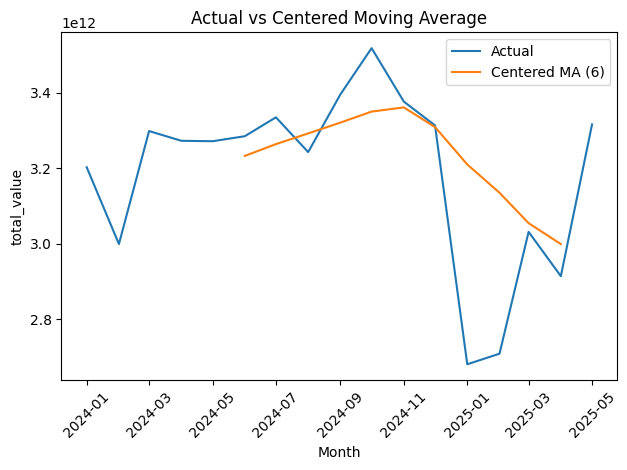

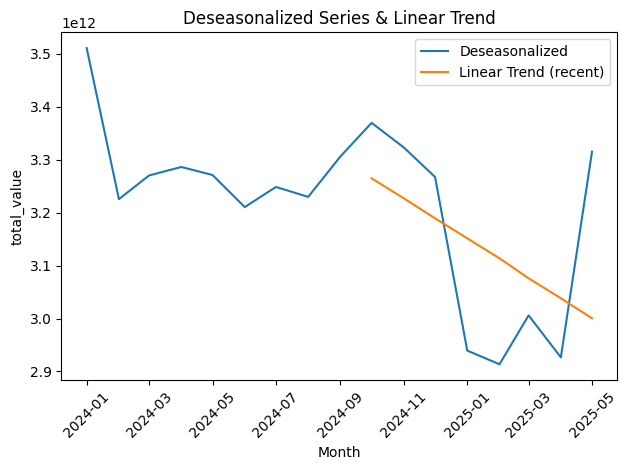

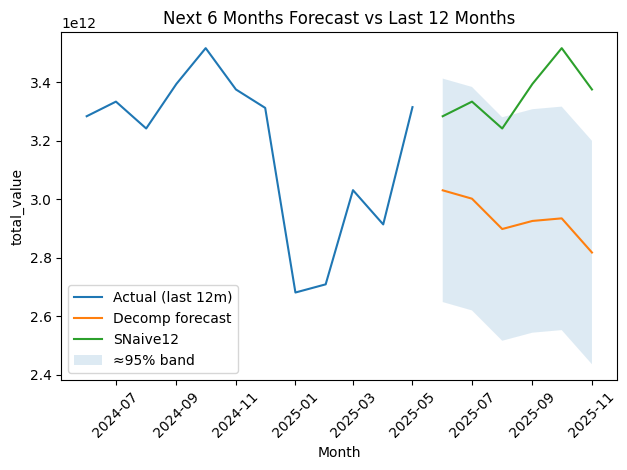

In [116]:
def robust_decomp_forecast(
    monthly_df,
    value_col="total_value",
    horizon=6,
    season=12,
    ma_window=12,      # can set 6 if you want a quicker trend
    shrink=0.4,        # 0 = use raw SI, 1 = no seasonality; 0.3–0.6 is good with short data
    recent_start=None  # e.g., "2024-10-01" to fit trend only on recent months
):
    df = monthly_df[["ref_date", value_col]].dropna().sort_values("ref_date").reset_index(drop=True)
    s = df.set_index("ref_date")[value_col].astype(float)
    idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(idx)

    # ---- centered moving average for trend ----
    if ma_window % 2 == 1:
        cma = s.rolling(ma_window, center=True).mean()
    else:
        ma  = s.rolling(ma_window, center=False).mean()
        cma = (ma + ma.shift(-1)) / 2.0

    # ---- seasonal indices (multiplicative), with shrinkage toward 1.0 ----
    ratios = (s / cma).dropna()
    si_by_month = ratios.groupby(ratios.index.month).mean()  # 1..12
    si_by_month = si_by_month.reindex(pd.Index(range(1, season+1), dtype=int))
    if si_by_month.isna().any():
        si_by_month = si_by_month.fillna(si_by_month.dropna().mean())
    si_norm = si_by_month / si_by_month.mean()
    si_shrunk = (1.0 - shrink) * si_norm + shrink * 1.0

    # expand to full timeline
    si_series = pd.Series(index=s.index, dtype=float)
    for m in range(1, season+1):
        si_series[s.index.month == m] = float(si_shrunk.loc[m])

    # ---- deseasonalize ----
    deseason = s / si_series

    # ---- choose window for trend fit ----
    if recent_start is not None:
        recent_start = pd.Timestamp(recent_start)
        mask = deseason.notna() & (deseason.index >= recent_start)
    else:
        mask = deseason.notna()

    t = np.arange(len(deseason))[mask.values]
    y = deseason[mask].values
    if len(t) < 2:
        raise ValueError("Not enough points to fit a trend on the chosen window.")
    b, a = np.polyfit(t, y, deg=1)  # y ≈ a + b t

    # in-sample fitted
    trend_hat = pd.Series(np.nan, index=deseason.index)
    trend_hat.iloc[mask] = a + b * t
    ltwS_fitted = trend_hat * si_series

    # ---- seasonal-naive (12) as a baseline forecast ----
    def snaive(series, steps=6, season=12):
        vals = []
        for i in range(steps):
            j = len(series) - season + i
            vals.append(series.iloc[j] if j >= 0 else series.iloc[-1])
        return np.array(vals)

    # ---- build future index & forecasts ----
    last_date = s.index.max()
    fidx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    t_future = np.arange(len(deseason), len(deseason)+horizon)
    trend_future = a + b * t_future
    si_future = pd.Series([float(si_shrunk.loc[m]) for m in fidx.month], index=fidx)
    yhat_decomp = trend_future * si_future.values
    yhat_snaive = snaive(s.dropna(), steps=horizon, season=season)

    # ---- simple uncertainty band from recent residuals ----
    common = pd.DataFrame({"y": s, "fit": ltwS_fitted}).dropna()
    resid = (common["y"] - common["fit"]).tail(6)  # last few residuals only
    sigma = resid.std(ddof=1) if len(resid) > 1 else np.nan
    band = 1.96 * sigma if sigma == sigma else None  # NaN-safe

    # ---- tables ----
    components = pd.DataFrame({
        "ref_date": s.index,
        "Actual": s.values,
        "CMA": cma.values,
        "SI_shrunk": si_series.values,
        "Deseasonalized": deseason.values,
        "Trend(a+bt)": trend_hat.values,
        "LTwS_fitted": ltwS_fitted.values
    }).set_index("ref_date")

    forecast = pd.DataFrame({
        "ref_date": fidx,
        "Trend_only": trend_future,
        "SI_used": si_future.values,
        "Forecast_decomp": yhat_decomp,
        "Forecast_SNaive12": yhat_snaive
    })
    if band is not None:
        forecast["lo_95"] = forecast["Forecast_decomp"] - band
        forecast["hi_95"] = forecast["Forecast_decomp"] + band

    meta = {
        "trend_intercept_a": a,
        "trend_slope_b": b,
        "ma_window": ma_window,
        "season": season,
        "shrink": shrink,
        "recent_start": str(recent_start) if recent_start else None
    }
    return components, forecast, si_shrunk, meta

# -------- run it (tweak ma_window/shrink/recent_start as you like) --------
components, forecast_6, seasonal_idx, meta = robust_decomp_forecast(
    monthly,
    value_col="total_value",   # or "total_kg"
    horizon=6,
    season=12,
    ma_window=6,               # try 6 if you want a quicker trend; 12 is the textbook
    shrink=0.4,                # 40% shrink toward no seasonality to avoid overfitting
    recent_start="2024-10-01"  # fit trend on recent regime (optional)
)

print(meta)
display(forecast_6)

# -------- plots (like your Excel) --------
plt.figure()
plt.plot(components.index, components["Actual"], label="Actual")
plt.plot(components.index, components["CMA"], label=f"Centered MA ({meta['ma_window']})")
plt.title("Actual vs Centered Moving Average")
plt.xlabel("Month"); plt.ylabel("total_value"); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(components.index, components["Deseasonalized"], label="Deseasonalized")
plt.plot(components.index, components["Trend(a+bt)"], label="Linear Trend (recent)")
plt.title("Deseasonalized Series & Linear Trend")
plt.xlabel("Month"); plt.ylabel("total_value"); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
hist = components.tail(12)
plt.plot(hist.index, hist["Actual"], label="Actual (last 12m)")
plt.plot(forecast_6["ref_date"], forecast_6["Forecast_decomp"], label="Decomp forecast")
plt.plot(forecast_6["ref_date"], forecast_6["Forecast_SNaive12"], label="SNaive12")
if "lo_95" in forecast_6:
    plt.fill_between(forecast_6["ref_date"], forecast_6["lo_95"], forecast_6["hi_95"], alpha=0.15, label="≈95% band")
plt.title("Next 6 Months Forecast vs Last 12 Months")
plt.xlabel("Month"); plt.ylabel("total_value"); plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()